## Figure 5 — Runtime Benchmark

Compares wall-clock runtimes of all five tools across four datasets of increasing
size (18k–172k cells). All values are hardcoded from measured runtimes.

GPU and CPU variants are shown separately for scAR and CellBender (dashed = GPU,
solid = CPU). Non-droplet datasets (WBC, BD Rhapsody) are marked with triangles.
CellClear has no measured value for the WBC dataset.

Also includes a radar chart (`performance_radar.png`) summarising per-tool scores
across Sensitivity, Specificity, Precision, Consistency, Speed, and Versatility —
all derived from results in Figures 2–4.

### Figures produced
- **Fig_5_runtime.png** — Log-log runtime vs. cell count line plot
- **Fig_5_radar.png** — Multi-panel radar chart of tool performance profiles

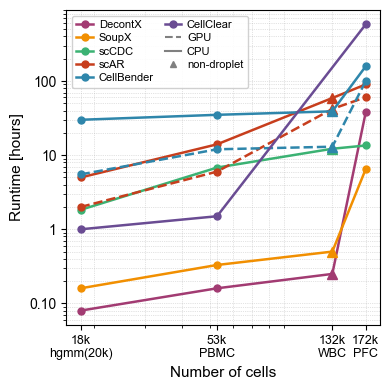

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
plt.rcParams['font.family'] = 'Arial'

times = {
    "DecontX":          [0.08, 0.16, 0.25, 38],
    "SoupX":            [0.16, 0.33, 0.5, 6.5],
    "scCDC":            [1.83, 6.8, 12.2, 13.5],
    "scAR (GPU)":       [2, 6, 42, 60.5],
    "scAR (CPU)":       [5, 14, 59, 90],
    "CellBender (GPU)": [5.5, 12, 13, 100],
    "CellBender (CPU)": [30, 35, 39, 158],
    "CellClear":        [1, 1.5, None, 582],
}
n_cells = [18000, 53000, 132000, 172000]
dataset_names = ["hgmm(20k)", "PBMC", "WBC", "PFC"]
droplet_based = [True, True, False, True]  # Hgmm, PBMC, WBC, PFC

colors = {
    "DecontX":          "#A23B72",
    "SoupX":            "#F18F01",
    "scAR (GPU)":       "#C73E1D",
    "scAR (CPU)":       "#C73E1D",
    "CellBender (GPU)": "#2E86AB",
    "CellBender (CPU)": "#2E86AB",
    "CellClear":        "#6A4C93",
    'scCDC' :           '#3BB273',
}


fig, ax = plt.subplots(figsize=(4, 4))

for label, vals in times.items():
    x = [n_cells[i] for i, v in enumerate(vals) if v is not None]
    y = [v for v in vals if v is not None]
    markers = ["o" if droplet_based[i] else "^" for i, v in enumerate(vals) if v is not None]
    ls = "--" if "(GPU)" in label else "-"
    # plot line without markers, then scatter per-point
    ax.plot(x, y, color=colors[label], linestyle=ls, linewidth=1.8)
    for xi, yi, mi in zip(x, y, markers):
        ax.plot(xi, yi, marker=mi, color=colors[label], markersize=7 if mi == "^" else 5)

ax.set_xscale("log")
ax.set_yscale("log")

# Custom x-ticks at dataset positions
ax.set_xticks(n_cells)
ax.set_xticklabels([f"{n/1000:.0f}k\n{name}" for n, name in zip(n_cells, dataset_names)], fontsize=9)

# Clean y-axis
ax.yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda y, _: f"{int(y)}" if y >= 1 else f"{y:.2f}"
))
ax.set_ylabel("Runtime [hours]", fontsize=11)
ax.set_xlabel("Number of cells", fontsize=11)

ax.grid(True, which="both", linestyle=":", linewidth=0.5, alpha=0.7)

handles, labels = ax.get_legend_handles_labels()
from matplotlib.lines import Line2D

tool_entries = [
    Line2D([0], [0], color=colors["DecontX"],          linestyle="-", linewidth=1.8, marker="o", markersize=5, label="DecontX"),
    Line2D([0], [0], color=colors["SoupX"],             linestyle="-", linewidth=1.8, marker="o", markersize=5, label="SoupX"),
    Line2D([0], [0], color=colors["scCDC"],             linestyle="-", linewidth=1.8, marker="o", markersize=5, label="scCDC"),
    Line2D([0], [0], color=colors["scAR (GPU)"],        linestyle="-", linewidth=1.8, marker="o", markersize=5, label="scAR"),
    Line2D([0], [0], color=colors["CellBender (GPU)"],  linestyle="-", linewidth=1.8, marker="o", markersize=5, label="CellBender"),
    Line2D([0], [0], color=colors["CellClear"],         linestyle="-", linewidth=1.8, marker="o", markersize=5, label="CellClear"),
]
style_entries = [
    Line2D([0], [0], color="gray", linestyle="--", linewidth=1.5, label="GPU"),
    Line2D([0], [0], color="gray", linestyle="-",  linewidth=1.5, label="CPU"),
    Line2D([0], [0], color="gray", linestyle="", marker="^", markersize=5, label="non-droplet"),
]

ax.legend(handles=tool_entries + style_entries, fontsize=8, framealpha=0.9,
          loc="upper left", handlelength=1.5, handletextpad=0.5, labelspacing=0.3,
          ncol=2, columnspacing=1.0)

plt.tight_layout()
plt.savefig("runtime_benchmark.png", dpi=300, bbox_inches="tight")
plt.show()

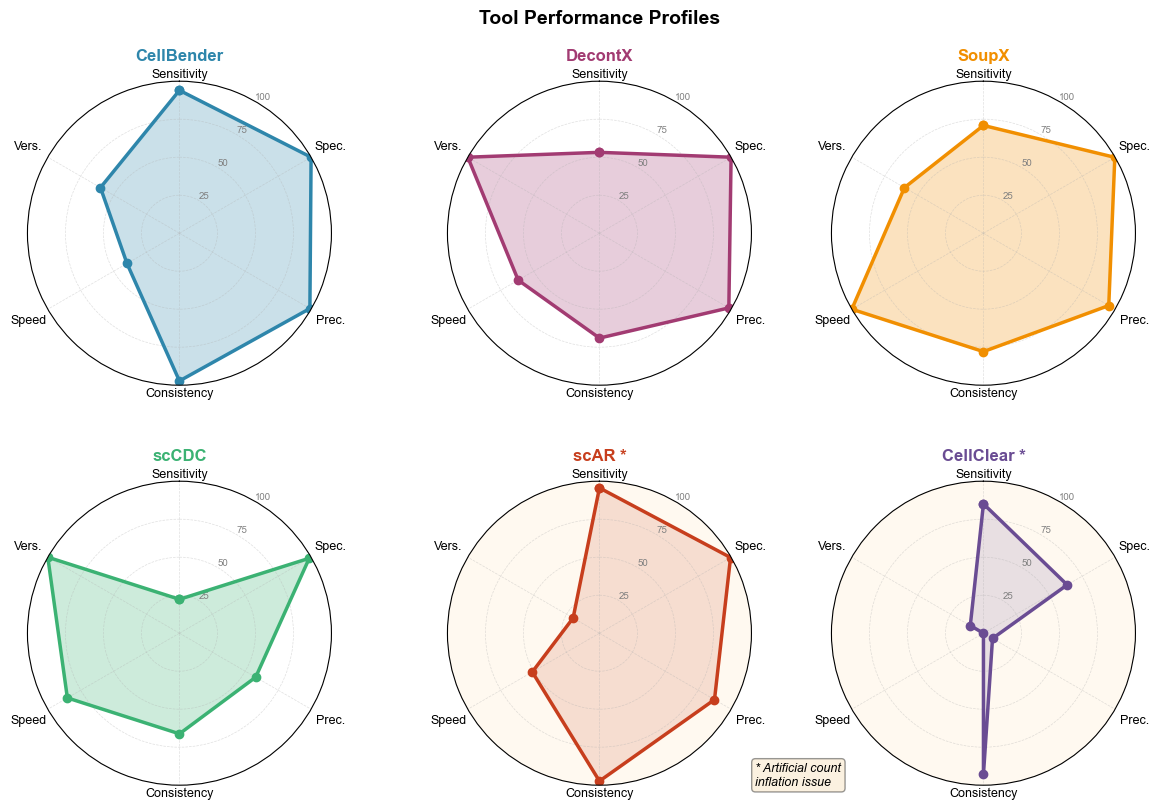

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# Data from your table and runtime plot
tool_data = {
    'CellBender': {
        'Sensitivity': 94,
        'Consistency': 97.2,
        'Precision': 99.1,
        'Specificity': 100.0,
        'Runtime_hours': 100,
        'Versatility': 60  # Requires raw data
    },
    'SoupX': {
        'Sensitivity': 70.9,
        'Consistency': 77.9,
        'Precision': 95.2,
        'Specificity': 99.8,
        'Runtime_hours': 7,
        'Versatility': 60
    },
    'DecontX': {
        'Sensitivity': 53.2,
        'Consistency': 69.0,
        'Precision': 98.3,
        'Specificity': 100.0,
        'Runtime_hours': 38,
        'Versatility': 100  # Works without raw data!
    },
    'scCDC': {
        'Sensitivity': 22.3,
        'Consistency': 66.2,
        'Precision': 57.9,
        'Specificity': 98.6,
        'Runtime_hours': 13.5, 
        'Versatility': 100  # Works without raw data!
    },
    
    'scAR': {
        'Sensitivity': 95.6,
        'Consistency': 97.3,
        'Precision': 87.4,
        'Specificity': 99.6,
        'Runtime_hours': 61,
        'Versatility': 20  # Artificial count inflation
    },
    'CellClear': {
        'Sensitivity': 85.1,
        'Consistency': 92.9,
        'Precision': 6.9,
        'Specificity': 63.6,
        'Runtime_hours': 582,
        'Versatility': 10  # Severe artificial count inflation
    }
}


# Normalize runtime to 0-100 scale (inverse: faster = higher score)
runtimes = [data['Runtime_hours'] for data in tool_data.values()]
max_runtime = max(runtimes)

import math
min_runtime = min(tool_data[t]['Runtime_hours'] for t in tool_data)  # SoupX = 6.5
max_runtime = max(tool_data[t]['Runtime_hours'] for t in tool_data)  # CellClear = 582

for tool in tool_data:
    # Inverse and normalize: fastest gets 100, slowest gets close to 0
    tool_data[tool]['Speed'] = 100 * (1 - (
        (math.log(tool_data[tool]['Runtime_hours']) - math.log(min_runtime)) /
        (math.log(max_runtime) - math.log(min_runtime))))


# Metrics to plot
categories = ['Sensitivity', 'Specificity', 'Precision', 'Consistency', 'Speed', 'Versatility']
display_labels = ['Sensitivity', 'Spec.', 'Prec.', 'Consistency', 'Speed', 'Vers.']
N = len(categories)

# Angle for each axis
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# Tool colors
tool_colors = {
    'CellBender': '#2E86AB',
    'DecontX': '#A23B72',
    'SoupX': '#F18F01',
    'scAR': '#C73E1D',
    'CellClear': '#6A4C93',
    'scCDC' : '#3BB273' ,
}

# Tool order for grid
tools_order = ['CellBender', 'DecontX', 'SoupX',  'scCDC', 'scAR', 'CellClear']

# Create 2x3 subplot grid

fig = plt.figure(figsize=(12, 8))

positions = [
    [0.01, 0.55, 0.28, 0.38],  # row 1 — pushed up, shorter
    [0.36, 0.55, 0.28, 0.38],
    [0.68, 0.55, 0.28, 0.38],
    [0.01, 0.05, 0.28, 0.38],  # row 2 — shorter
    [0.36, 0.05, 0.28, 0.38],
    [0.68, 0.05, 0.28, 0.38],
]

axes = [fig.add_axes(pos, projection='polar') for pos in positions]

for idx, tool in enumerate(tools_order):
    ax = axes[idx]
    
    # # Shrink the polar axis to create padding
    # pos = ax.get_position()
    # shrink = -0.15  # Adjust this value (0.1-0.2 works well)
    # ax.set_position([pos.x0 + shrink*pos.width, 
    #                  pos.y0 + shrink*pos.height,
    #                  pos.width * (1-2*shrink), 
    #                  pos.height * (1-2*shrink)])
    
    # Get values for this tool
    values = [tool_data[tool][cat] for cat in categories]
    values += values[:1]
    
    # Plot
    color = tool_colors[tool]
    alpha = 0.15 if tool in ['scAR', 'CellClear'] else 0.25
    
    ax.plot(angles, values, 'o-', linewidth=2.5, color=color)
    ax.fill(angles, values, alpha=alpha, color=color)
    
    # Styling
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    # Styling
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])  # Remove default labels
    
    # Manually place labels with custom padding
    label_padding = {
        'Sensitivity': 1.05,      # Top - normal
        'Specificity': 1.15,      # Right - more padding
        'Precision': 1.15,        # Bottom-right - more padding
        'Consistency': 1.05,      # Bottom - normal
        'Speed': 1.15,            # Bottom-left - more padding
        'Versatility': 1.15       # Left - more padding
    }
    
    for angle, label, display_label in zip(angles[:-1], categories, display_labels):
        pad = label_padding[label]  # Still use full name for padding lookup
        ax.text(angle, pad * 100, display_label, size=9, 
                horizontalalignment='center', verticalalignment='center')
    
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75, 100])
    ax.set_yticklabels(['25', '50', '75', '100'], size=7, color='gray')
    ax.set_rlabel_position(180 / N)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
    
    # Title with warning for problematic tools
    title = tool
    if tool in ['scAR', 'CellClear']:
        title += ' *'
        ax.set_facecolor('#FFF9F0')  # Subtle warning background
    
    ax.set_title(title, size=12, weight='bold', pad=15, color=color)


# Add footnote
# fig.text(0.85, 0.22, '* Artificial count\ninflation issue', 
#          fontsize=10, style='italic',
#          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

fig.text(0.63, 0.05, '* Artificial count\ninflation issue', 
         fontsize=9, style='italic',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

plt.suptitle('Tool Performance Profiles', size=14, weight='bold', y=1.02)

#plt.tight_layout(h_pad=3.0)  # Increase vertical padding


plt.savefig('figure_3_data/performance_radar.png', dpi=300, bbox_inches='tight')
plt.show()